In [2]:
import cv2
import numpy as np
import torch
from PIL import Image
import os
from deeplabv3.utils import image_overlay
from torchvision import transforms
import matplotlib.pyplot as plt
import onnxruntime as ort

In [3]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Infected area ratio: 0.48
Тяжелое поражение


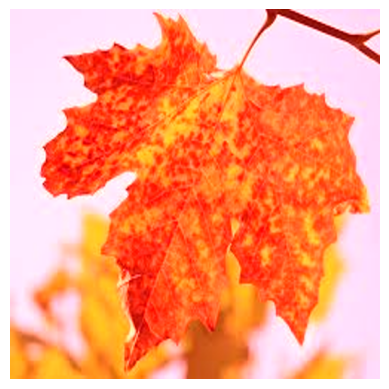

In [4]:
image_path = "C:/PythonProjects/plant_disease_class"
# image_name = "C:/PythonProjects/plant_disease_class/new_plant/test/test/test_photo_1.jpg"
image_name = "C:/PythonProjects/plant_disease_class/maple_leaf.jpg"
model_path = "outputs/inference_results/deeplabv3_resnet50.onnx"

# Загружаем изображение
image = Image.open(os.path.join(image_path, image_name))

# Преобразуем изображение в стандартный размер, например 512x512
image = image.resize((512, 512))

# Преобразуем изображение в тензор и нормализуем
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

image_tensor = transform(image).unsqueeze(0).numpy()  # Преобразуем в numpy массив

# Загружаем ONNX модель с помощью onnxruntime
ort_session = ort.InferenceSession(model_path)

# Получаем имя входного тензора модели
input_name = ort_session.get_inputs()[0].name

# Выполняем инференс
outputs = ort_session.run(None, {input_name: image_tensor})

# Извлекаем результат
segmented_image = np.argmax(outputs[0], axis=1)[0]  # Извлекаем предсказания для первого изображения из батча

# Для анализа используем только класс, который соответствует заражению (например, класс 1)
infected_class = 1  # Пример класса, который будет указывать на зараженные участки

# Массив с маской зараженной области
infected_area_mask = segmented_image == infected_class

# Рассчитываем площадь пораженных участков
infected_area = np.sum(infected_area_mask)
total_area = infected_area_mask.size

# Пропорция зараженных пикселей
infection_ratio = infected_area / total_area
print(f"Infected area ratio: {infection_ratio:.2f}")

# Оценка степени заболевания на основе площади
if infection_ratio < 0.1:
    print("Малое поражение")
elif infection_ratio < 0.3:
    print("Среднее поражение")
else:
    print("Тяжелое поражение")

# Визуализация (если необходимо)
segmented_image_color = cv2.applyColorMap(segmented_image.astype(np.uint8), cv2.COLORMAP_JET)
final_image = cv2.cvtColor(image_overlay(image, segmented_image_color), cv2.COLOR_BGR2RGB)

# Покажем изображение с помощью Matplotlib
plt.imshow(final_image)
plt.axis('off')  # Отключим оси
plt.show()